## PLOT TENDENCY BUDGETS

In [1]:
import xarray as xr
import numpy as np
import os
import sys
import dask
import h5netcdf
import scipy
import netCDF4
import argparse
import matplotlib.pyplot as plt
import sys
sys.path.append(".")  # Ensures the current directory is in the Python path
sys.path.append("/home/paaa/python_scripts/")
import my_functions as mfun


In [2]:
readdir = '/perm/paaa/IFS/maritime_c'
savedir = '/perm/paaa/images'
exp_ids      = ["iuko","iukr"]
subdomain = 'maritime_c'
lbud23 = True

In [3]:
def rename_vars_lbud23(ds):
    # Combined dictionary: old_name -> (new_name, unit)
    LBUD23 = {
        'p91' : ('dudt_dyn',     'm s$^{-2}$ *s'),
        'p92' : ('dvdt_dyn',     'm s$^{-2}$ *s'),
        'p93' : ('dTdt_dyn',     'K s$^{-1}$ *s'),
        'p94' : ('dqdt_dyn',     'g kg$^{-1}$ s$^{-1}$ *s'),
        
        'p95' : ('dTdt_rad',     'K s$^{-1}$ *s'),
        
        'p96' : ('dudt_diff',    'm s$^{-2}$ *s'),
        'p97' : ('dvdt_diff',    'm s$^{-2}$ *s'),
        'p98' : ('dTdt_diff',    'K s$^{-1}$ *s'),
        'p99' : ('dqdt_diff',    'g kg$^{-1}$ s$^{-1}$ *s'),
        
        'p100': ('dudt_gwave',   'm s$^{-2}$ *s'),
        'p101': ('dvdt_gwave',   'm s$^{-2}$ *s'),
        'p102': ('dTdt_gwave',   'K s$^{-1}$ *s'),
        
        'p103': ('dudt_conv',    'm s$^{-2}$ *s'),
        'p104': ('dvdt_conv',    'm s$^{-2}$ *s'),
        'p105': ('dTdt_conv',    'K s$^{-1}$ *s'),
        'p106': ('dqdt_conv',    'g kg$^{-1}$ s$^{-1}$ *s'),
        
        'p107': ('prflx_conv_l', 'kg m$^{-2}$ s$^{-1}$ *s'),
        'p108': ('prflx_conv_i', 'kg m$^{-2}$ s$^{-1}$ *s'),
        
        'p109': ('dTdt_cloud',   'K s$^{-1}$ *s'),
        'p110': ('dqdt_cloud',   'g kg$^{-1}$ s$^{-1}$ *s'),
        'p111': ('dqldt_cloud',  'g kg$^{-1}$ s$^{-1}$ *s'),
        'p112': ('dqidt_cloud',  'g kg$^{-1}$ s$^{-1}$ *s'),
        
        'p113': ('prflx_stra_l', 'kg m$^{-2}$ s$^{-1}$ *s'),
        'p114': ('prflx_stra_i', 'kg m$^{-2}$ s$^{-1}$ *s'),
        
        'p115': ('dTdt_rad_SW',  'K s$^{-1}$ *s'),
    }

    # Create rename mapping only (old_name -> new_name)
    rename_map = {old: new for old, (new, _) in LBUD23.items()}
    ds = ds.rename(rename_map)

    # Assign units directly
    for old, (new, unit) in LBUD23.items():
        if new in ds:
            # Special scaling for dqdt and similar variables
            if any(tag in new for tag in ['dqdt', 'dco2dt', 'dch4dt']):
                ds[new] *= 1000
            ds[new].attrs['units'] = unit

    return ds

In [ ]:
def convert_to_height_levels(ds_ml, top_height=4000, hlevs=None):
    """
    Convert model-level data to fixed height levels using hydrostatic balance.
    
    Parameters
    ----------
    ds_ml : xr.Dataset
        Dataset containing model-level data with a 'level' coordinate.
        Must contain at least temperature ('t') and specific humidity ('q').
        Must also contain either 'lnsp' or 'sp' to compute pressure.
    mfun : module
        Physics module with at least:
          - calc_rho(p, T, q) to compute density
          - g (gravitational acceleration constant)
    top_lev : int, optional
        Index of the top model level to include (default=1).
    hlevs : list or np.ndarray, optional
        Fixed target height levels (in m). If None, a default set is used.
    
    Returns
    -------
    ds_z : xr.Dataset
        New dataset interpolated to fixed height levels with 'height' as the vertical coordinate.
    """

    # Hybrid coefficients (A and B)
    a= np.array([ 2.000365, 3.102241, 4.666084, 6.827977, 9.746966, 13.605424, 18.608931, 24.985718,
                 32.985710, 42.879242, 54.955463, 69.520576, 86.895882, 107.415741, 131.425507,
                 159.279404, 191.338562, 227.968948, 269.539581, 316.420746, 368.982361, 427.592499,
                 492.616028, 564.413452, 643.339905, 729.744141, 823.967834, 926.344910, 1037.201172,
                 1156.853638, 1285.610352, 1423.770142, 1571.622925, 1729.448975, 1897.519287, 2076.095947,
                 2265.431641, 2465.770508, 2677.348145, 2900.391357, 3135.119385, 3381.743652, 3640.468262,
                 3911.490479, 4194.930664, 4490.817383, 4799.149414, 5119.895020, 5452.990723, 5798.344727,
                 6156.074219, 6526.946777, 6911.870605, 7311.869141, 7727.412109, 8159.354004, 8608.525391,
                 9076.400391, 9562.682617, 10065.978516, 10584.631836, 11116.662109, 11660.067383, 12211.547852,
                 12766.873047, 13324.668945, 13881.331055, 14432.139648, 14975.615234, 15508.256836, 16026.115234, 16527.322266, 17008.789062, 17467.613281, 17901.621094, 18308.433594, 18685.718750, 19031.289062, 19343.511719, 19620.042969, 19859.390625, 20059.931641, 20219.664062, 20337.863281, 20412.308594, 20442.078125, 20425.718750, 20361.816406, 20249.511719, 20087.085938, 19874.025391, 19608.572266, 19290.226562, 18917.460938, 18489.707031, 18006.925781, 17471.839844, 16888.687500, 16262.046875, 15596.695312, 14898.453125, 14173.324219, 13427.769531, 12668.257812, 11901.339844, 11133.304688, 10370.175781, 9617.515625, 8880.453125, 8163.375000, 7470.343750, 6804.421875, 6168.531250, 5564.382812, 4993.796875, 4457.375000, 3955.960938, 3489.234375, 3057.265625, 2659.140625, 2294.242188, 1961.500000, 1659.476562, 1387.546875, 1143.250000, 926.507812, 734.992188, 568.062500, 424.414062, 302.476562, 202.484375, 122.101562, 62.781250, 22.835938, 3.757813, 0.000000, 0.000000
                 ])
    b = np.array([ 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
                  0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
                  0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
                  0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
                  0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
                  0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
                  0.000007, 0.000024, 0.000059, 0.000112, 0.000199, 0.000340, 0.000562, 0.000890, 0.001353,
                  0.001992, 0.002857, 0.003971, 0.005378, 0.007133, 0.009261, 0.011806, 0.014816, 0.018318,
                  0.022355, 0.026964, 0.032176, 0.038026, 0.044548, 0.051773, 0.059728, 0.068448, 0.077958,
                  0.088286, 0.099462, 0.111505, 0.124448, 0.138313, 0.153125, 0.168910, 0.185689, 0.203491,
                  0.222333, 0.242244, 0.263242, 0.285354, 0.308598, 0.332939, 0.358254, 0.384363, 0.411125,
                  0.438391, 0.466003, 0.493800, 0.521619, 0.549301, 0.576692, 0.603648, 0.630036, 0.655736,
                  0.680643, 0.704669, 0.727739, 0.749797, 0.770798, 0.790717, 0.809536, 0.827256, 0.843881, 0.859432, 0.873929, 0.887408, 0.899900, 0.911448, 0.922096, 0.931881, 0.940860, 0.949064, 0.956550, 0.963352, 0.969513, 0.975078, 0.980072, 0.984542, 0.988500, 0.991984, 0.995003, 0.997630, 1.000000
                  ])
    # Expand dimensions of 'b' to match surface_pressure and Convert to DataArrays
    a_da = xr.DataArray(a, dims="level")  # Assign 'levels' as the dimension
    b_da = xr.DataArray(b, dims="level")  # Assign 'levels' as the dimension

    # -------------------------
    # 1. Compute pressure
    # -------------------------
    if 'lnsp' in ds_ml:
        print("Using lnsp to compute pressure levels.")
        lnsp = ds_ml['lnsp'].sel(level=1).reset_coords('level', drop=True)
        p_half = a_da + (b_da * np.exp(lnsp))
    elif 'sp' in ds_ml:
        print("Using sp to compute pressure levels.")
        sp = ds_ml['sp'].reset_coords('level', drop=True)
        p_half = a_da + b_da * sp
    else:
        raise ValueError("Dataset must contain either 'lnsp' or 'sp' for surface pressure.")


    # Mid-layer pressure
    top_lev = min(ds_ml.level.values[1:])
    print(f"Highest model level (except 1): {top_lev}")

    p_ml = (p_half.isel(level=slice(top_lev-2, -1)) + p_half.isel(level=slice(top_lev-1, None))) / 2
    p_ml = p_ml.assign_coords(level=np.arange(top_lev, 138))
    ds_ml['p'] = p_ml
    ds_ml['p'].attrs['long_name'] = 'pressure'

    # -------------------------
    # 2. Compute heights
    # -------------------------
    dp = p_ml.diff(dim="level")
    T = ds_ml['t'].sel(level=p_ml['level'])
    q = ds_ml['q'].sel(level=p_ml['level']) / 1000  # g/kg -> kg/kg
    print(f'Make sure specific humidity q is in g/kg before calling the function')

    rho = mfun.calc_rho(p_ml, T, q)
    dz = dp / (rho * mfun.g)

    # Integrate from top down
    dz_rev = dz.sortby("level", ascending=False)
    z_accum = dz_rev.cumsum(dim="level").sortby("level")
    h_0 = 0                         # surface level = 0
    h_levels = h_0 + z_accum
    # -------------------------
    # 3. Determine target height levels
    # -------------------------
    mean_hlevs = np.sort(h_levels.mean(("time", "latitude", "longitude")))
    if hlevs is None:
        # Keep only values between 0 and 4000
        hlevs = mean_hlevs[(mean_hlevs >= 0) & (mean_hlevs <= top_height)]

    # -------------------------
    # 5. Apply to all variables vectorised
    # -------------------------
    ds_z = xr.Dataset(
        coords={
            "time": ds_ml.time,
            "latitude": ds_ml.latitude,
            "longitude": ds_ml.longitude,
            "height": hlevs, 
        }
    )

    # Add empty variables for each data variable in ds_ml, initialised with NaNs
    for var in ds_ml.data_vars:
        ds_z[var] = xr.DataArray(
            np.full((len(ds_ml.time), len(ds_ml.latitude), len(ds_ml.longitude), len(hlevs)), np.nan),
            dims=("time", "latitude", "longitude", "height"),
            coords=ds_z.coords,
            attrs=ds_ml[var].attrs  # Preserve attributes
        )
    ds_z['height'].attrs.update({'units': 'm', 'long_name': 'Height from the surface'})

    for it in ds_ml.time:
        if it.dt.hour == 0 or it.dt.hour == 12:
            print('time:', str(it.values)[0:10])
        for ilat in ds_ml.latitude:
            # print('lat:', str(ilat.values)[0:5])
            for ilon in ds_ml.longitude:
                # print('lon:', str(ilon.values)[0:5])
                
                # Select data at current time, lat, lon
                ifs_it = ds_ml.sel(level=slice(top_lev+1, 137), time=it, latitude=ilat, longitude=ilon)
                # Assign height as a coordinate and swap dims
                ifs_it = ifs_it.assign_coords(
                    {"height": ("level", h_levels.sel(time=it, latitude=ilat, longitude=ilon).values)}
                ).swap_dims({"level": "height"})

                # Interpolate to fixed heights
                ifs_it = ifs_it.interp(height=hlevs, kwargs={"fill_value": "extrapolate"})

                # Assign interpolated values into the preallocated dataset
                ds_z.loc[dict(time=it, latitude=ilat, longitude=ilon)] = ifs_it

    return ds_z


In [7]:
ds = {}
for exp in exp_ids:
    file=f'{readdir}/{exp}_tendencies_{subdomain}.nc'
    ds[exp] = xr.open_dataset(file,engine='netcdf4')
    ds[exp] = rename_vars_lbud23(ds[exp])
    ds[exp] = ds[exp].sel(time=ds[exp].time.dt.hour == 0)
    for var in ['co2','q','clwc','ra','co','ch4']:
        if var in ds[exp]:
            ds[exp][var] *= 1000 
            ds[exp][var].attrs['units'] = r'g kg$^{-1}$'
        

In [54]:
ds_z = {}
for exp in exp_ids:
    ds_z[exp] = convert_to_height_levels(ds[exp][['dudt_conv','t','lnsp','q']].isel(time=slice(0,2)),top_height=4000)
    # ds_z[exp] = convert_to_height_levels(ds[exp],top_height=7000)

#### not working becase vars are flipped ony axis 

Using lnsp to compute pressure levels.
Highest model level (except 1): 50
Make sure specific humidity q is in g/kg before calling the function
time: 2022-06-02
lat: 20.0
lat: 19.8
lat: 19.6
lat: 19.4
lat: 19.2
lat: 19.0
lat: 18.8
lat: 18.6
lat: 18.4
lat: 18.2
lat: 18.0
lat: 17.8
lat: 17.6
lat: 17.4
lat: 17.2
lat: 17.0
lat: 16.8
lat: 16.6
lat: 16.4
lat: 16.2
lat: 16.0
lat: 15.8
lat: 15.6
lat: 15.4
lat: 15.2
lat: 15.0
lat: 14.8
lat: 14.6
lat: 14.4
lat: 14.2
lat: 14.0
lat: 13.8
lat: 13.6
lat: 13.4
lat: 13.2
lat: 13.0
lat: 12.8
lat: 12.6
lat: 12.4
lat: 12.2
lat: 12.0
lat: 11.8
lat: 11.6
lat: 11.4
lat: 11.2
lat: 11.0
lat: 10.8
lat: 10.6
lat: 10.4
lat: 10.2
lat: 10.0
lat: 9.8
lat: 9.6
lat: 9.4
lat: 9.2
lat: 9.0
lat: 8.8
lat: 8.6
lat: 8.4
lat: 8.2
lat: 8.0
lat: 7.8
lat: 7.6
lat: 7.4
lat: 7.2
lat: 7.0
lat: 6.8
lat: 6.6
lat: 6.4
lat: 6.2
lat: 6.0
lat: 5.8
lat: 5.6
lat: 5.4
lat: 5.2
lat: 5.0
lat: 4.8
lat: 4.6
lat: 4.4
lat: 4.2
lat: 4.0
lat: 3.8
lat: 3.6
lat: 3.4
lat: 3.2
lat: 3.0
lat: 2.8
lat: 2

KeyboardInterrupt: 

In [8]:
ds[exp]

<xarray.Dataset> Size: 5GB
Dimensions:       (time: 8, longitude: 301, latitude: 201, level: 89)
Coordinates:
  * time          (time) datetime64[ns] 64B 2022-06-02 2022-06-03 ... 2022-06-09
  * longitude     (longitude) float32 1kB 120.0 120.2 120.4 ... 179.8 180.0
  * latitude      (latitude) float32 804B 20.0 19.8 19.6 ... -19.6 -19.8 -20.0
  * level         (level) int32 356B 1 50 51 52 53 54 ... 133 134 135 136 137
Data variables: (12/30)
    dudt_dyn      (time, level, latitude, longitude) float32 172MB ...
    dvdt_dyn      (time, level, latitude, longitude) float32 172MB ...
    dTdt_dyn      (time, level, latitude, longitude) float32 172MB ...
    dqdt_dyn      (time, level, latitude, longitude) float32 172MB -0.0001888...
    dTdt_rad      (time, level, latitude, longitude) float32 172MB ...
    dudt_diff     (time, level, latitude, longitude) float32 172MB ...
    ...            ...
    dTdt_rad_SW   (time, level, latitude, longitude) float32 172MB ...
    z             (time, level, latitude, longitude) float32 172MB ...
    lnsp          (time, level, latitude, longitude) float32 172MB ...
    t             (time, level, latitude, longitude) float32 172MB ...
    q             (time, level, latitude, longitude) float32 172MB 0.002643 ....
    p             (level, time, latitude, longitude) float64 345MB nan ... 1....
Attributes:
    CDI:          Climate Data Interface version 2.5.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Sep 03 13:36:29 2025: cdo mergetime iukr_tendencies_mar...
    CDO:          Climate Data Operators version 2.5.1 (https://mpimet.mpg.de...

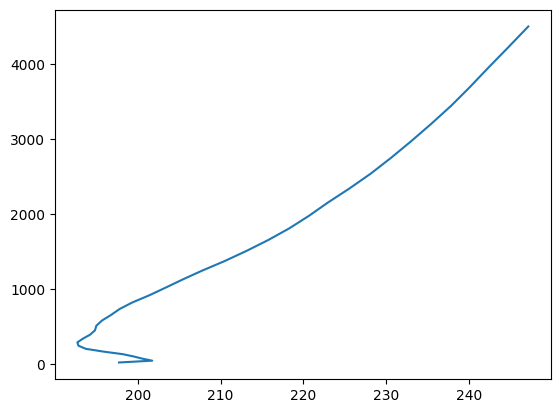

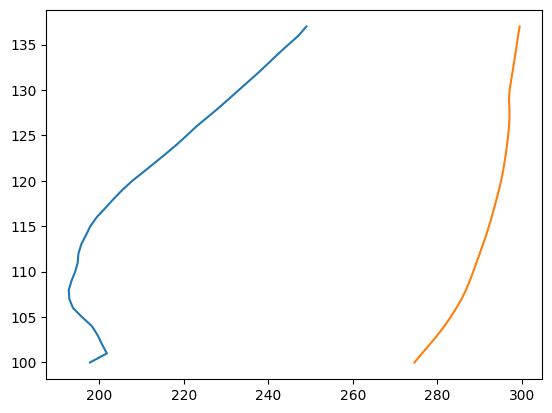

In [33]:
plt.figure()
plt.plot(ds_z[exp]['t'].isel(time=0).isel(height=slice(0,37)).isel(latitude=10,longitude=10).values,\
         ds_z[exp]['height'].isel(height=slice(0,37)))
plt.figure()
plt.plot(ds_z[exp]['t'].isel(time=0).isel(height=slice(0,38)).isel(latitude=10,longitude=10).values,\
         ds[exp]['level'].sel(level=slice(100,137)))
plt.plot(ds[exp]['t'].isel(time=0).sel(level=slice(100,137)).isel(latitude=10,longitude=10).values,\
         ds[exp]['level'].sel(level=slice(100,137)))


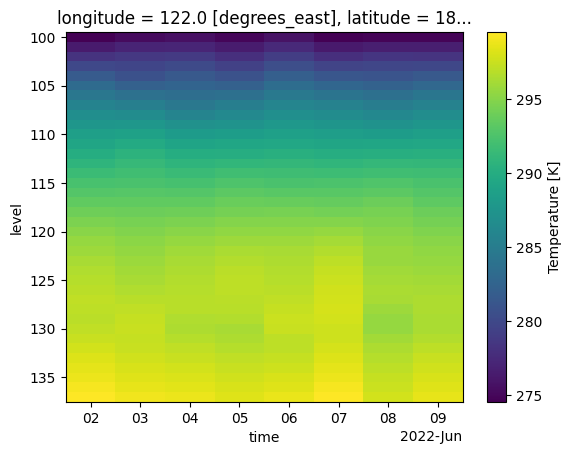

In [13]:
plt.figure()
ds[exp]['t'].sel(level=slice(100,137)).isel(latitude=10,longitude=10).plot(y='level',yincrease=False)


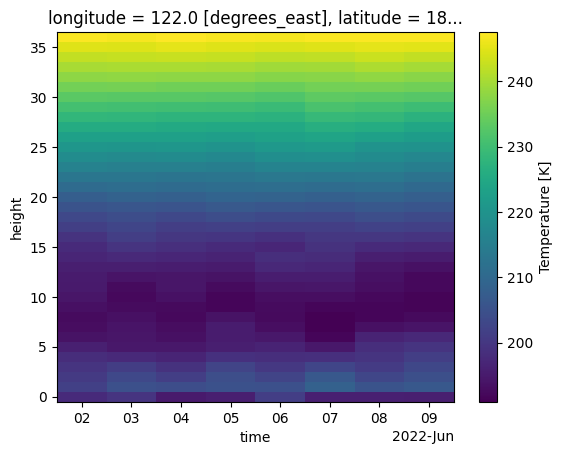

In [60]:
ds_z['t'].isel(height=slice(0,37)).isel(latitude=10,longitude=10).plot(y='height',yincrease=True)

In [17]:
diff = ds['iuko'] - ds['iukr']

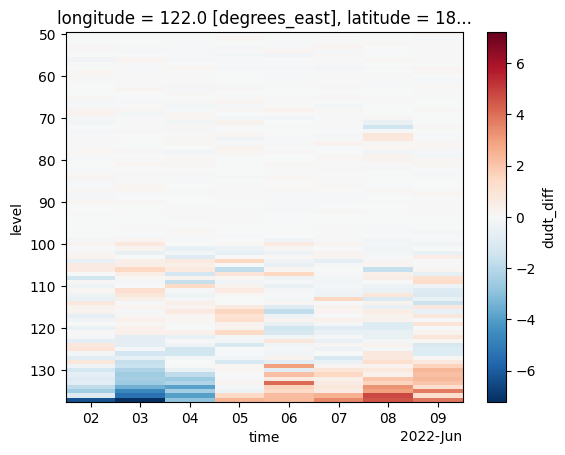

In [19]:
diff['dudt_diff'].sel(level=slice(50,137)).isel(latitude=10,longitude=10).plot(y='level',yincrease=False)